In [42]:
# laster modell og encoder 
from pathlib import Path
import numpy as np
import pandas as pd
import joblib

ROOT = Path("..")  # fordi notebook ligger i notebooks/
MODEL_PATH = ROOT / "ml/models/random_forest_example_binary.joblib"
ENCODER_PATH = ROOT / "ml/models/label_encoder_example_binary.joblib"
TEST_PATH = ROOT / "ml/datasets/processed/test.csv"

model = joblib.load(MODEL_PATH)
encoder = joblib.load(ENCODER_PATH)

model, encoder.classes_ 

(RandomForestClassifier(class_weight='balanced_subsample', n_estimators=300,
                        n_jobs=-1, random_state=42),
 array(['aluminium_kule', 'stål_kule'], dtype=object))

In [ ]:
#dataset sample og numerisk label
full_df = pd.read_csv(ROOT / "ml/datasets/processed/triad_features_example_binary.csv")

klasse_counts = full_df["label_object"].value_counts()

klasse_mapping = pd.DataFrame({
    "Numerisk label": range(len(encoder.classes_)),
    "Klasse": encoder.classes_,
})

klasse_mapping["Antall samples"] = klasse_mapping["Klasse"].map(klasse_counts).fillna(0).astype(int)
klasse_mapping["Andel"] = klasse_mapping["Antall samples"] / len(full_df)
klasse_mapping["Antall klasser i datasettet"] = full_df["label_object"].nunique()
klasse_mapping["Totalt antall samples"] = len(full_df)

klasse_mapping

,Numerisk label,Klasse,Antall samples,Andel,Antall klasser i datasettet,Totalt antall samples
0,0,aluminium_kule,26,0.5,2,52
1,1,stål_kule,26,0.5,2,52


In [59]:
#model performance metrikker
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt
y_true = df["label_object"].astype(str)
y_pred = resultat["prediksjon"].astype(str)

labels = list(encoder.classes_)
y_true = df["label_object"].astype(str)
y_pred = resultat["prediksjon"].astype(str)

labels = list(encoder.classes_)

In [60]:
#model performance metrikker
metrics_df = pd.DataFrame({
    "Metrikk": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Verdi": [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average="weighted", zero_division=0),
        recall_score(y_true, y_pred, average="weighted", zero_division=0),
        f1_score(y_true, y_pred, average="weighted", zero_division=0),
    ],
})

metrics_df.style.format({
    "Verdi": "{:.3f}"
})

,Metrikk,Verdi
0,Accuracy,0.875
1,Precision,0.900
2,Recall,0.875
3,F1-score,0.873


In [ ]:
#klassespesifikke metrikker
rapport = classification_report(
    y_true,
    y_pred,
    labels=labels,
    output_dict=True,
    zero_division=0,
)

rapport_df = pd.DataFrame(rapport).T
rapport_df
rapport_df.style.format("{:.3f}")

,precision,recall,f1-score,support
aluminium_kule,0.800,1.000,0.889,4.000
stål_kule,1.000,0.750,0.857,4.000
accuracy,0.875,0.875,0.875,0.875
macro avg,0.900,0.875,0.873,8.000
weighted avg,0.900,0.875,0.873,8.000


In [ ]:
#konfusjonsmatrise tabell
cm = confusion_matrix(y_true, y_pred, labels=labels)

cm_df = pd.DataFrame(
    cm,
    index=[f"Fasit: {label}" for label in labels],
    columns=[f"Predikert: {label}" for label in labels],
)

cm_df

,Predikert: aluminium_kule,Predikert: stål_kule
Fasit: aluminium_kule,4,0
Fasit: stål_kule,1,3


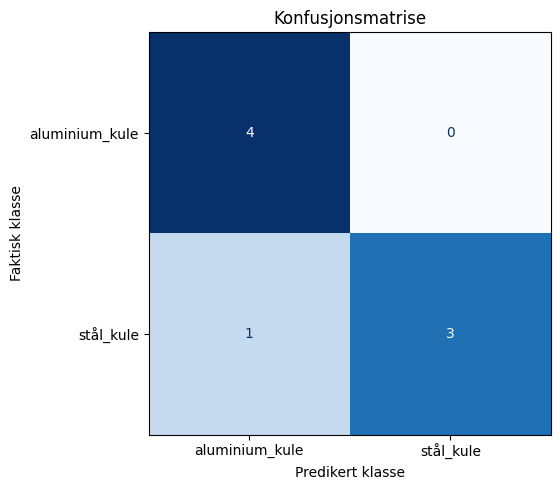

In [ ]:
#konfusjonsmatrise plot
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False,
)

ax.set_title("Konfusjonsmatrise")
ax.set_xlabel("Predikert klasse")
ax.set_ylabel("Faktisk klasse")

plt.tight_layout()
plt.show()

In [ ]:
# regner ut prediksjon og sannsynlighet for hver test sampel
pred_idx = probs.argmax(axis=1)
pred_label = encoder.inverse_transform(pred_idx)
confidence = probs.max(axis=1)

resultat = df.copy()
resultat["prediksjon"] = pred_label
resultat["confidence"] = confidence
resultat["p_aluminium_kule"] = proba_df["aluminium_kule"]
resultat["p_stål_kule"] = proba_df["stål_kule"]

resultat[[
    "sample_id",
    "label_object",
    "prediksjon",
    "confidence",
    "p_aluminium_kule",
    "p_stål_kule",
]]

,sample_id,label_object,prediksjon,confidence,p_aluminium_kule,p_stål_kule
0,S0021,stål_kule,stål_kule,0.920000,0.080000,0.920000
1,S0027,aluminium_kule,aluminium_kule,0.586667,0.586667,0.413333
2,S0036,aluminium_kule,aluminium_kule,0.730000,0.730000,0.270000
3,S0004,stål_kule,aluminium_kule,0.696667,0.696667,0.303333
4,S0046,aluminium_kule,aluminium_kule,0.706667,0.706667,0.293333
5,S0001,stål_kule,stål_kule,0.633333,0.366667,0.633333
6,S0009,stål_kule,stål_kule,0.870000,0.130000,0.870000
7,S0033,aluminium_kule,aluminium_kule,0.580000,0.580000,0.420000


In [45]:
feature_importance = pd.DataFrame({
    "feature": model.feature_names_in_,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

top_features = feature_importance.head(15)
top_features

,feature,importance
178,std_31,0.051898
53,max_26,0.031794
172,std_26,0.029138
181,std_34,0.027464
32,derivative_S1_860_900,0.024121
179,std_32,0.023309
80,mean_18,0.022942
174,std_28,0.021950
158,std_13,0.019915
150,sam_to_aluminium,0.019418


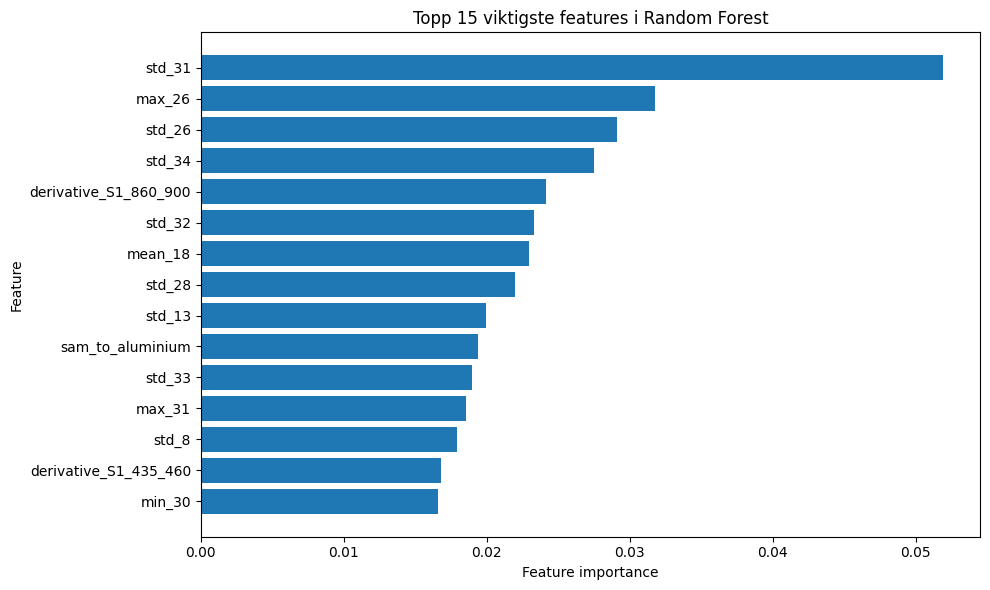

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Topp 15 viktigste features i Random Forest")
plt.tight_layout()
plt.show()

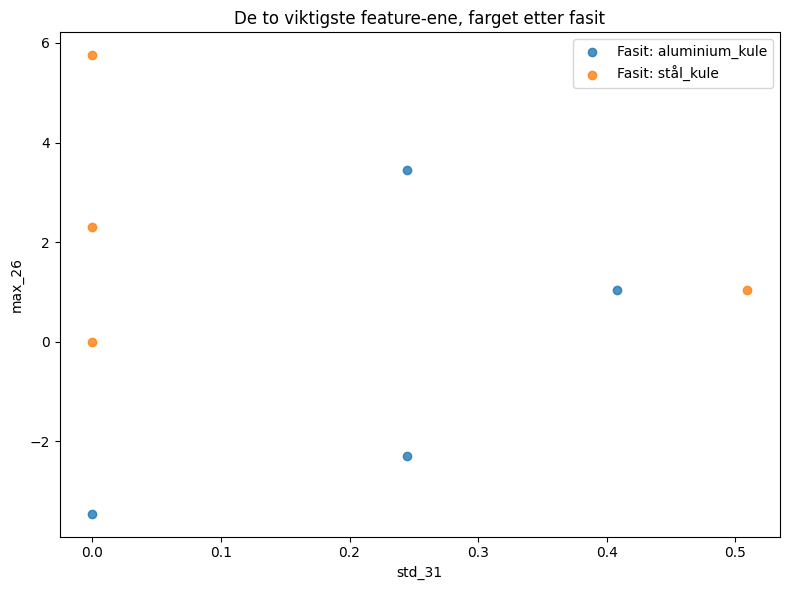

In [47]:
f1, f2 = feature_importance["feature"].iloc[0], feature_importance["feature"].iloc[1]

plot_df = df.copy()
plot_df["prediksjon"] = resultat["prediksjon"]

plt.figure(figsize=(8, 6))

for klasse in labels:
    subset = plot_df[plot_df["label_object"] == klasse]
    plt.scatter(
        subset[f1],
        subset[f2],
        label=f"Fasit: {klasse}",
        alpha=0.8,
    )

plt.xlabel(f1)
plt.ylabel(f2)
plt.title("De to viktigste feature-ene, farget etter fasit")
plt.legend()
plt.tight_layout()
plt.show()

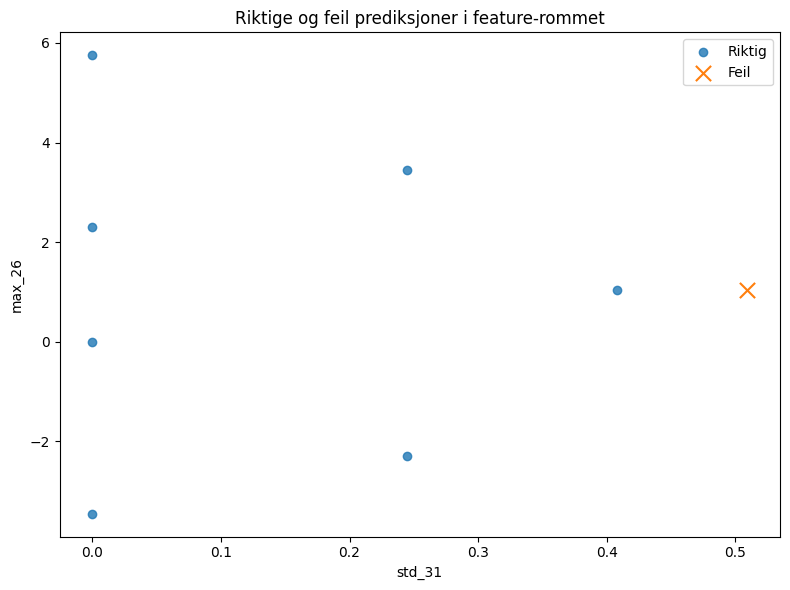

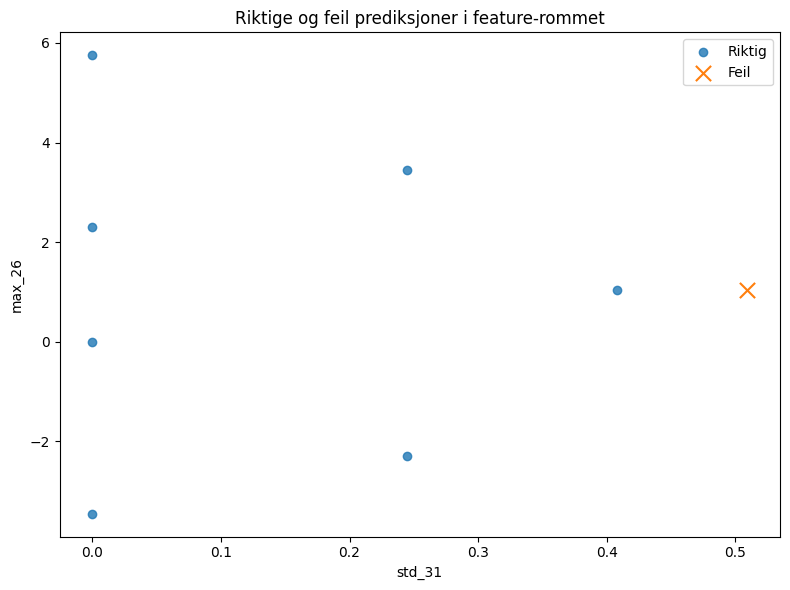

In [51]:
plot_df["riktig"] = plot_df["label_object"] == plot_df["prediksjon"]

plt.figure(figsize=(8, 6))

riktig = plot_df[plot_df["riktig"]]
feil = plot_df[~plot_df["riktig"]]

plt.scatter(riktig[f1], riktig[f2], label="Riktig", alpha=0.8)
plt.scatter(feil[f1], feil[f2], label="Feil", marker="x", s=120)

plt.xlabel(f1)
plt.ylabel(f2)
plt.title("Riktige og feil prediksjoner i feature-rommet")
plt.legend()
plt.tight_layout()
plt.show()
plot_df["riktig"] = plot_df["label_object"] == plot_df["prediksjon"]

plt.figure(figsize=(8, 6))

riktig = plot_df[plot_df["riktig"]]
feil = plot_df[~plot_df["riktig"]]

plt.scatter(riktig[f1], riktig[f2], label="Riktig", alpha=0.8)
plt.scatter(feil[f1], feil[f2], label="Feil", marker="x", s=120)

plt.xlabel(f1)
plt.ylabel(f2)
plt.title("Riktige og feil prediksjoner i feature-rommet")
plt.legend()
plt.tight_layout()
plt.show()

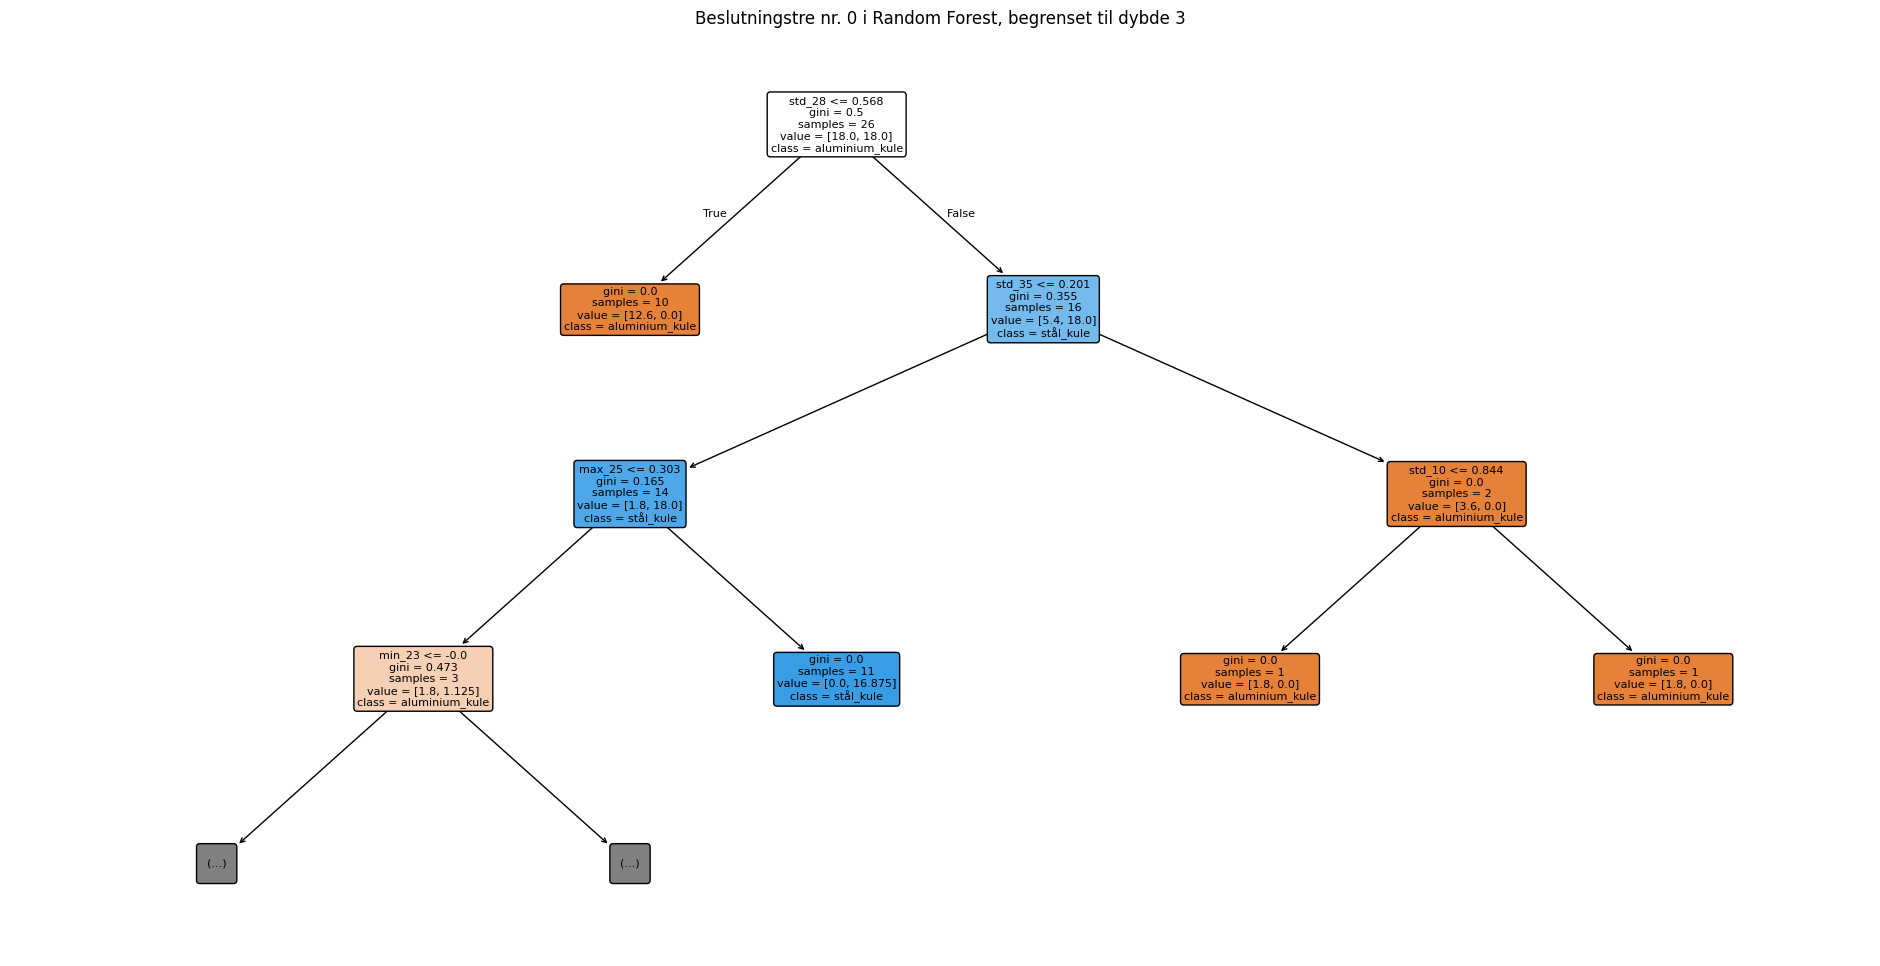

In [52]:
from sklearn.tree import plot_tree

tree_index = 0
tree = model.estimators_[tree_index]

plt.figure(figsize=(24, 12))

plot_tree(
    tree,
    feature_names=list(model.feature_names_in_),
    class_names=list(encoder.classes_),
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)

plt.title(f"Beslutningstre nr. {tree_index} i Random Forest, begrenset til dybde 3")
plt.show()

In [62]:
sample_id = "S0021"

sample_row = resultat[resultat["sample_id"] == sample_id]
sample_index = sample_row.index[0]

x_sample = X.loc[[sample_index]]

tree_votes = []

for tree in model.estimators_:
    vote_idx = tree.predict(x_sample)[0]
    tree_votes.append(int(vote_idx))

vote_counts = pd.Series(tree_votes).value_counts().sort_index()

vote_df = pd.DataFrame({
    "klasse_index": vote_counts.index,
    "antall_trær": vote_counts.values,
})

vote_df["klasse"] = encoder.inverse_transform(vote_df["klasse_index"])
vote_df["andel_trær"] = vote_df["antall_trær"] / len(model.estimators_)

vote_df

/home/farr97/MoonmapperDT/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/home/farr97/MoonmapperDT/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/home/farr97/MoonmapperDT/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/home/farr97/MoonmapperDT/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/home/farr97/MoonmapperDT/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without f

,klasse_index,antall_trær,klasse,andel_trær
0,0,24,aluminium_kule,0.08
1,1,276,stål_kule,0.92


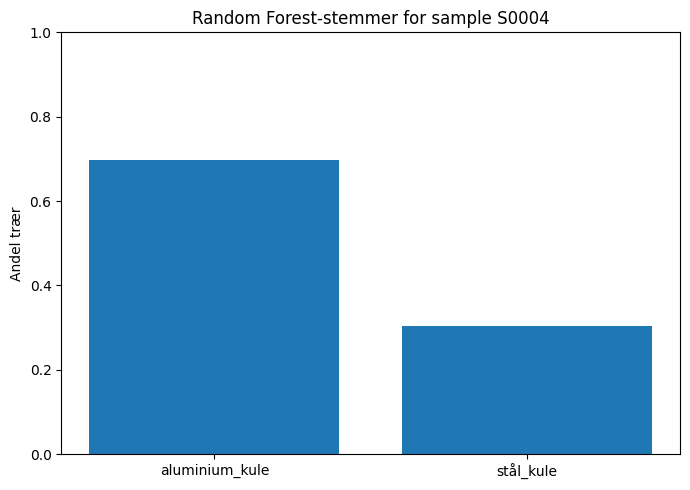

In [54]:
plt.figure(figsize=(7, 5))
plt.bar(vote_df["klasse"], vote_df["andel_trær"])
plt.ylabel("Andel trær")
plt.title(f"Random Forest-stemmer for sample {sample_id}")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

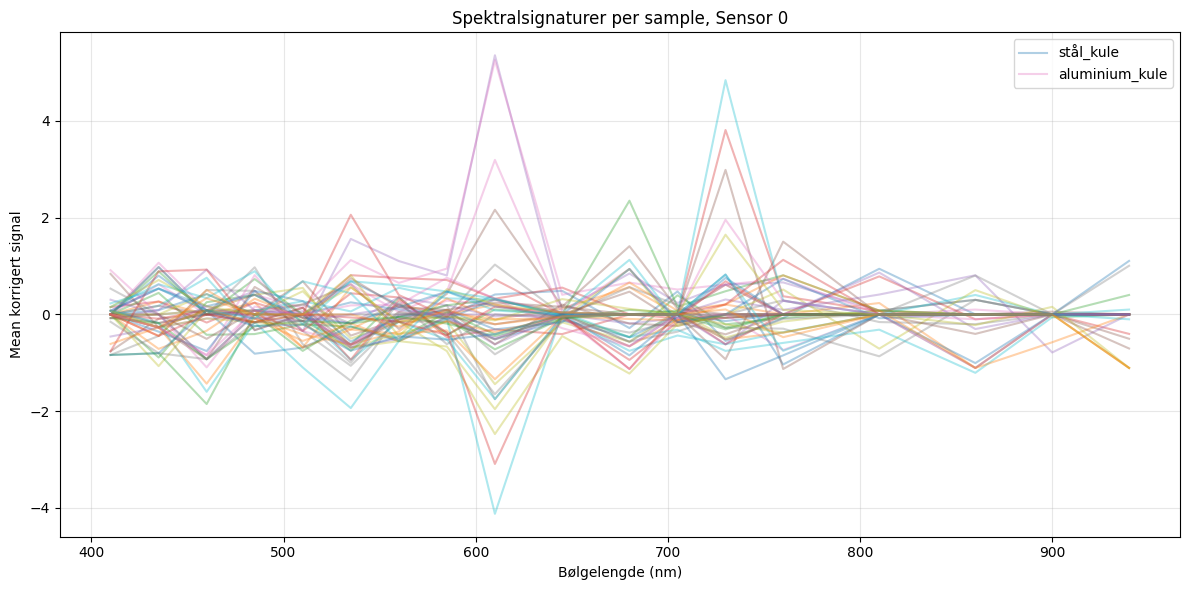

In [ ]:
#26 kurver sensor 0
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

full_df = pd.read_csv(ROOT / "ml/datasets/processed/triad_features_example_binary.csv")

wavelengths = np.array([
    410, 435, 460, 485, 510, 535, 560, 585, 610,
    645, 680, 705, 730, 760, 810, 860, 900, 940
])

sensor0_cols = [f"mean_{i}" for i in range(18)]
sensor1_cols = [f"mean_{i}" for i in range(18, 36)]

classes = full_df["label_object"].unique()
classes

plt.figure(figsize=(12, 6))

for klasse in classes:
    subset = full_df[full_df["label_object"] == klasse]

    for _, row in subset.iterrows():
        y = row[sensor0_cols].values.astype(float)
        plt.plot(wavelengths, y, alpha=0.35, label=klasse if _ == subset.index[0] else None)

plt.xlabel("Bølgelengde (nm)")
plt.ylabel("Mean korrigert signal")
plt.title("Spektralsignaturer per sample, Sensor 0")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

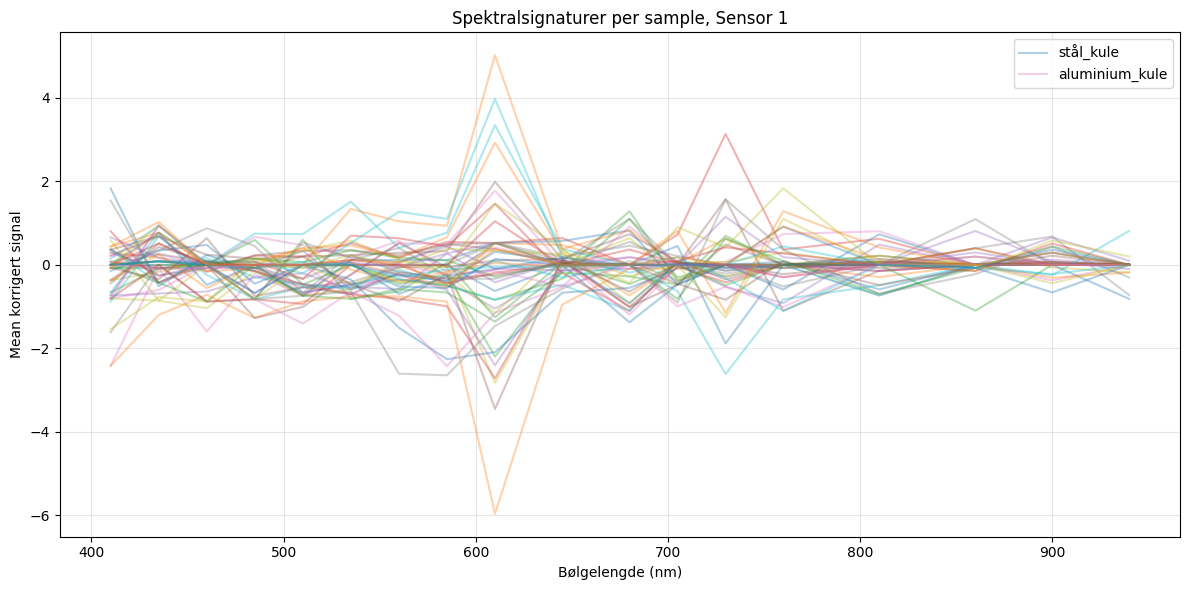

In [ ]:
#26 kurver sensor 1
plt.figure(figsize=(12, 6))

for klasse in classes:
    subset = full_df[full_df["label_object"] == klasse]

    for _, row in subset.iterrows():
        y = row[sensor1_cols].values.astype(float)
        plt.plot(wavelengths, y, alpha=0.35, label=klasse if _ == subset.index[0] else None)

plt.xlabel("Bølgelengde (nm)")
plt.ylabel("Mean korrigert signal")
plt.title("Spektralsignaturer per sample, Sensor 1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

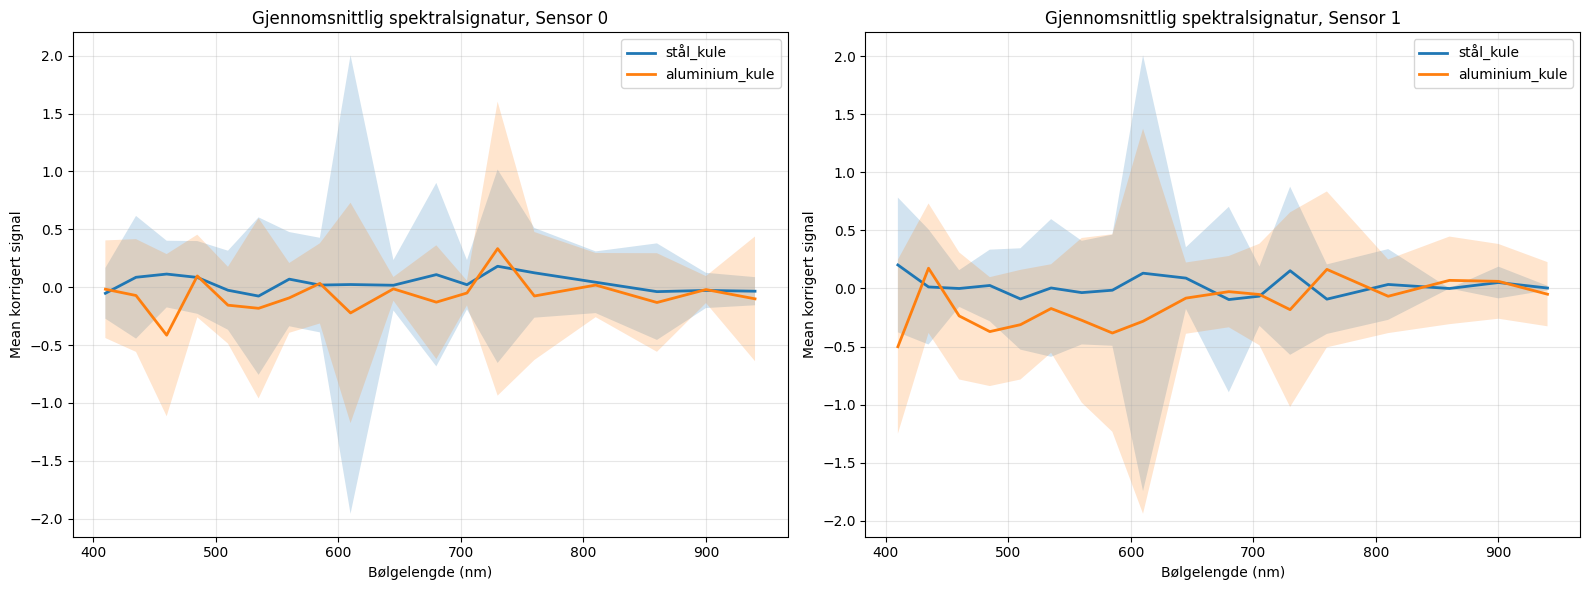

In [ ]:
#gjennomsnittskurve med standardavvik 
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, sensor_cols, sensor_name in [
    (axes[0], sensor0_cols, "Sensor 0"),
    (axes[1], sensor1_cols, "Sensor 1"),
]:
    for klasse in classes:
        subset = full_df[full_df["label_object"] == klasse]
        values = subset[sensor_cols].astype(float).values

        mean_curve = values.mean(axis=0)
        std_curve = values.std(axis=0)

        ax.plot(wavelengths, mean_curve, label=klasse, linewidth=2)
        ax.fill_between(
            wavelengths,
            mean_curve - std_curve,
            mean_curve + std_curve,
            alpha=0.2,
        )

    ax.set_title(f"Gjennomsnittlig spektralsignatur, {sensor_name}")
    ax.set_xlabel("Bølgelengde (nm)")
    ax.set_ylabel("Mean korrigert signal")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [44]:
#dataset entropy: hvor blandet klassene er

DATASETS = {
    "train": ROOT / "ml/datasets/processed/train.csv",
    "val": ROOT / "ml/datasets/processed/val.csv",
    "test": ROOT / "ml/datasets/processed/test.csv",
    "all": ROOT / "ml/datasets/processed/triad_features_example_binary.csv",
}

LABEL_COLUMN = "label_object"

def dataset_entropy(df, label_column=LABEL_COLUMN):
    counts = df[label_column].value_counts()
    probabilities = counts / counts.sum()

    entropy_bits = -np.sum(probabilities * np.log2(probabilities))
    max_entropy_bits = np.log2(len(counts))
    normalized_entropy = entropy_bits / max_entropy_bits if max_entropy_bits > 0 else 0

    return pd.Series({
        "n_samples": counts.sum(),
        "n_classes": len(counts),
        "entropy_bits": entropy_bits,
        "max_entropy_bits": max_entropy_bits,
        "normalized_entropy": normalized_entropy,
        **{f"count_{label}": count for label, count in counts.items()},
        **{f"p_{label}": prob for label, prob in probabilities.items()},
    })

entropy_rows = []

for name, path in DATASETS.items():
    df_split = pd.read_csv(path)
    row = dataset_entropy(df_split)
    row["dataset"] = name
    entropy_rows.append(row)

entropy_df = pd.DataFrame(entropy_rows).set_index("dataset")
entropy_df

,n_samples,n_classes,entropy_bits,max_entropy_bits,normalized_entropy,count_stål_kule,count_aluminium_kule,p_stål_kule,p_aluminium_kule
dataset,,,,,,,,,
train,36.0,2.0,1.0,1.0,1.0,18.0,18.0,0.5,0.5
val,8.0,2.0,1.0,1.0,1.0,4.0,4.0,0.5,0.5
test,8.0,2.0,1.0,1.0,1.0,4.0,4.0,0.5,0.5
all,52.0,2.0,1.0,1.0,1.0,26.0,26.0,0.5,0.5


In [40]:
#model entropy: hvor sikkert modellen er
def prediction_entropy(probs):
    p = np.asarray(probs, dtype=float)
    p = np.clip(p, 1e-12, 1.0)
    return -np.sum(p * np.log2(p), axis=1)

model_entropy = prediction_entropy(probs)

max_model_entropy = np.log2(len(encoder.classes_))
model_entropy_normalized = model_entropy / max_model_entropy

resultat["model_entropy_bits"] = model_entropy
resultat["model_entropy_normalized"] = model_entropy_normalized

resultat[[
    "sample_id",
    "label_object",
    "prediksjon",
    "confidence",
    "p_aluminium_kule",
    "p_stål_kule",
    "model_entropy_bits",
    "model_entropy_normalized",
]]
print("Gjennomsnittlig model entropy:", resultat["model_entropy_bits"].mean())
print("Median model entropy:", resultat["model_entropy_bits"].median())
print("Maks model entropy:", resultat["model_entropy_bits"].max())
print("Min model entropy:", resultat["model_entropy_bits"].min())

Gjennomsnittlig model entropy: 0.808393445594787
Median model entropy: 0.8791578743784372
Maks model entropy: 0.9814538950336537
Min model entropy: 0.4021791902022728
